<img src="https://github.com/nicholasmetherall/digital-earth-pacific-macblue-activities/blob/main/attachments/images/DE_Pacific_banner.JPG?raw=true" width="900"/>

Figure 1.1.a. Jupyter environment + Python notebooks

# Digital Earth Pacific Notebook 1 prepare postcard and load data to csv

The objective of this notebook is to prepare a geomad postcard for your AOI (masking, scaling and loading additional band ratios and spectral indices) and sampling all the datasets into a csv based on your training data geodataframe.

## Step 1.1: Configure the environment

In [1]:
from datetime import datetime
from shapely.geometry import Polygon
from shapely import box
from pyproj import CRS 
import folium
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio as rio
import xarray as xr
import rioxarray
import joblib
from ipyleaflet import basemaps
import pystac_client
from dask.distributed import Client as DaskClient
from odc.stac import load, configure_s3_access
import planetary_computer
from odc.stac import load
from pystac.client import Client
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt
from matplotlib import colors
from utils import load_data, load_s1_dem, scale, calculate_band_indices, apply_mask, mask_water, all_masks, do_prediction

In [2]:
# Reload scripts and imports
%load_ext autoreload
%autoreload 2

In [3]:
# Predefined variable for title and version

# Enter your initials
initials = "nm"

# Enter your site name
site = "tongatapu"

# Date
date = datetime.now()

# Make a clean version string
version = f"{initials}-{site}-{date.strftime('%d%m%Y')}"
print(version)

nm-tongatapu-20042026


## Step 1.2: Configure STAC access and search parameters

In [4]:
catalog = "https://stac.digitalearthpacific.org"
client = Client.open(catalog)

In [5]:
## Use training data bounds

# training = gpd.read_file(f"training-data/nm-{site}.geojson")
training = gpd.read_file("training-data/nm-tongatapu-11122025_postcard_4.geojson")
training = training.to_crs("EPSG:4326")
min_lon, min_lat, max_lon, max_lat = training.total_bounds

bbox = [min_lon, min_lat, max_lon, max_lat]

In [6]:
training

,LULC_code,LULC_class,geometry
0,6,Water,POINT (-175.32648 -21.05595)
1,6,Water,POINT (-175.36156 -21.09345)
2,6,Water,POINT (-175.12939 -21.27945)
3,6,Water,POINT (-175.02447 -21.1477)
4,6,Water,POINT (-175.31365 -21.16867)
...,...,...,...
985,4,Settlements,POINT (-175.1994 -21.13518)
986,4,Settlements,POINT (-175.19913 -21.13671)
987,4,Settlements,POINT (-175.20174 -21.13612)
988,4,Settlements,POINT (-175.20039 -21.13224)


In [7]:
training.columns.unique()

Index(['LULC_code', 'LULC_class', 'geometry'], dtype='object')

In [8]:
# bbox = [178.410921, -18.188382, 178.46952, -18.14731]

In [9]:
datetime = "2023"

items = client.search(
    collections=["dep_s2_geomad"],
    datetime=datetime,
    bbox=bbox
).item_collection()

print(f"Found {len(items)} items in for {datetime}")

Found 1 items in for 2023


In [10]:
measurements = ["nir", "red", "blue", "green", "emad", "smad", "bcmad", "green", "nir08", "nir09", "swir16", "swir22", "coastal", "rededge1", "rededge2", "rededge3"]
data = load_data(
    items,
    measurements,
    bbox,
)
    
# Now you can use the 'data' variable
print(data)

<xarray.Dataset> Size: 359MB
Dimensions:      (y: 2654, x: 3753, time: 1)
Coordinates:
  * y            (y) float64 21kB -2.383e+06 -2.383e+06 ... -2.41e+06 -2.41e+06
  * x            (x) float64 30kB 3.856e+06 3.856e+06 ... 3.893e+06 3.893e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 8B 2023-01-01
Data variables: (12/15)
    nir          (time, y, x) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    red          (time, y, x) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    blue         (time, y, x) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) uint16 20MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    emad         (time, y, x) float32 40MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    smad         (time, y, x) float32 40MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    ...           ...
    swir16       (time, y, x) uint16 20MB

In [11]:
# dask_client = DaskClient(n_workers=1, threads_per_worker=16, memory_limit='16GB')
# configure_s3_access(cloud_defaults=True, requester_pays=True)

In [12]:
scaled = scale(data)
scaled = scaled.compute().squeeze()

In [13]:
scaled = calculate_band_indices(scaled)
# Dataset = scaled
# Dataset.odc.explore(vmin = 0, vmax = 0.3, bands = ["red", "green", "blue"], crs="EPSG:3832", name=site)

In [14]:
# All masks
masked_scaled, mask = all_masks(scaled, return_mask = True)
# masked_scaled.odc.explore(vmin=0, vmax=0.3, bands=["red", "green", "blue"], crs="EPSG:3832", name=site)

In [15]:
masked_scaled

<xarray.Dataset> Size: 2GB
Dimensions:        (y: 2654, x: 3753)
Coordinates:
  * y              (y) float64 21kB -2.383e+06 -2.383e+06 ... -2.41e+06
  * x              (x) float64 30kB 3.856e+06 3.856e+06 ... 3.893e+06 3.893e+06
    spatial_ref    int32 4B 3832
    time           datetime64[ns] 8B 2023-01-01
Data variables: (12/32)
    nir            (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    red            (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    blue           (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    green          (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    emad           (y, x) float32 40MB nan nan nan nan nan ... nan nan nan nan
    smad           (y, x) float32 40MB nan nan nan nan nan ... nan nan nan nan
    ...             ...
    ndci           (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    nbi            (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    ndmi           (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    bsi            (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    awei           (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan
    tc_wetness     (y, x) float64 80MB nan nan nan nan nan ... nan nan nan nan

In [16]:
# combined_ds = masked_scaled.drop_vars("count")
combined_da = masked_scaled.to_dataarray()
combined_da = combined_da.squeeze()#.stack(dims=["y", "x"])#.transpose()
stacked_arrays_2d = combined_da.stack(new_dim=("y", "x")) 
reordered_data_array = stacked_arrays_2d.transpose('new_dim', 'variable')
stacked_arrays_2d.shape

(32, 9960462)

In [17]:
# Replace any infinities with NaN
stacked_arrays_2d = stacked_arrays_2d.where(stacked_arrays_2d != float("inf"))
stacked_arrays_2d = stacked_arrays_2d.where(stacked_arrays_2d != float("-inf"))

# Replace any NaN values with 0
df = stacked_arrays_2d.squeeze().fillna(0).transpose().to_pandas()

# Remove the all-zero rows
zero_mask = (df == 0).all(axis=1)  # Creates a boolean Series
non_zero_df = df.loc[~zero_mask]  # Filters out all-zero rows

# Create a new array to hold the predictions
full_pred = pd.Series(np.nan, index=df.index)

reordered_data_array = stacked_arrays_2d.transpose('new_dim', 'variable')

### Model training

In [18]:
reordered_data_array

<xarray.DataArray (new_dim: 9960462, variable: 32)> Size: 3GB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    spatial_ref  int32 4B 3832
    time         datetime64[ns] 8B 2023-01-01
  * variable     (variable) object 256B 'nir' 'red' ... 'awei' 'tc_wetness'
  * new_dim      (new_dim) object 80MB MultiIndex
  * y            (new_dim) float64 80MB -2.383e+06 -2.383e+06 ... -2.41e+06
  * x            (new_dim) float64 80MB 3.856e+06 3.856e+06 ... 3.893e+06

In [19]:
# # Reproject training data to the GeoMAD CRS and convert to xarray
# training_reprojected = training.to_crs(masked_scaled.odc.crs)
# training_da = training_reprojected.assign(
#     x=training_reprojected.geometry.x, y=training_reprojected.geometry.y
# ).to_xarray()

# # Extract training values from the masked dataset
# training_values = (
#     masked_scaled.sel(training_da[["x", "y"]], method="nearest")
#     .squeeze()
#     .compute()
#     .to_pandas()
# )
# training_values

In [20]:
model = joblib.load("models/nm-tongatapu-11122025-test.model")

In [21]:
# Predict the classes
predicted = model.predict(reordered_data_array)

In [22]:
# print("Prediction Input CRS:", reordered_data_array.rio.crs)
print("Prediction Input CRS:", data.rio.crs)

Prediction Input CRS: EPSG:3832


In [23]:
# Reshape back to the original 2D array
reordered_data_array = predicted.reshape(len(masked_scaled.y), len(masked_scaled.x))

# Convert to an xarray again, because it's easier to work with
predicted_da = xr.DataArray(
    reordered_data_array, coords={"y": masked_scaled.y, "x": masked_scaled.x}, dims=["y", "x"]
)

In [24]:
print(predicted_da.dtype)  # Check the dtype of your DataArray
predicted_da = predicted_da.astype('float32')  # Convert to float32

# Check for NaN values
if np.isnan(predicted_da).any():
    print("NaN values found in the data")
    # Handle NaN values, e.g. by filling them
    predicted_da = predicted_da.fillna(-9999)  # Replace NaN with 0 or appropriate value

object


In [25]:
masked_scaled = masked_scaled.compute()

In [26]:
# masked_scaled = masked_scaled.drop_vars("count")

predicted = do_prediction(masked_scaled, model)
predicted
# predicted.odc.explore(cmap=c_map, tiles=basemaps.Esri.WorldImagery)

<xarray.DataArray (y: 2654, x: 3753)> Size: 80MB
array([['6', '6', '6', ..., '6', '6', '6'],
       ['6', '6', '6', ..., '6', '6', '6'],
       ['6', '6', '6', ..., '6', '6', '6'],
       ...,
       ['6', '6', '6', ..., '6', '6', '6'],
       ['6', '6', '6', ..., '6', '6', '6'],
       ['6', '6', '6', ..., '6', '6', '6']], dtype=object)
Coordinates:
  * y        (y) float64 21kB -2.383e+06 -2.383e+06 ... -2.41e+06 -2.41e+06
  * x        (x) float64 30kB 3.856e+06 3.856e+06 ... 3.893e+06 3.893e+06

In [27]:
print(predicted)

<xarray.DataArray (y: 2654, x: 3753)> Size: 80MB
array([['6', '6', '6', ..., '6', '6', '6'],
       ['6', '6', '6', ..., '6', '6', '6'],
       ['6', '6', '6', ..., '6', '6', '6'],
       ...,
       ['6', '6', '6', ..., '6', '6', '6'],
       ['6', '6', '6', ..., '6', '6', '6'],
       ['6', '6', '6', ..., '6', '6', '6']], dtype=object)
Coordinates:
  * y        (y) float64 21kB -2.383e+06 -2.383e+06 ... -2.41e+06 -2.41e+06
  * x        (x) float64 30kB 3.856e+06 3.856e+06 ... 3.893e+06 3.893e+06


In [28]:
predicted = predicted.where(mask)
# `prediction` is your predicted class array# `mask` is your boolean mask, where True means masked
nodata_value = -9998  # or -9999, or whatever you chooseprediction_with_mask = prediction.copy()
predicted['mask'] = nodata_value

In [29]:
predicted_filled = predicted.fillna(-9999)
predicted_int = predicted_filled.astype(np.int32)

In [30]:
# predicted.odc.write_cog("prediction_serua_3b.tif")

In [31]:
from matplotlib import colors

# Updated classes list to include No Data (Code 0)
classes = [
    [0, 'No_Data', '#00000000'], # <-- NEW: Code 0 mapped to a light gray color
    [1, 'Forest_land', '#064a00'],
    [2, 'Grazing_Cropland', '#FFEE8C' ],
    [3, 'Wetland', '#73ffd2'],
    [4, 'Settlements', '#bd0007'],
    [5, 'Bare_land','#919191'],
    [6, 'Water','#71a8ff'],
]

# classes = [ 
#     [1, 'Forest_land', '#064a00'],
#     [2, 'Grazing_Cropland', '#b67e00' ],
#     [3, 'Wetland', '#73ffd2'],
#     [4, 'Settlements', '#bd0007'],
#     [5, 'Bare_land','#919191'],
#     [6, 'Water','#71a8ff'],
# ]


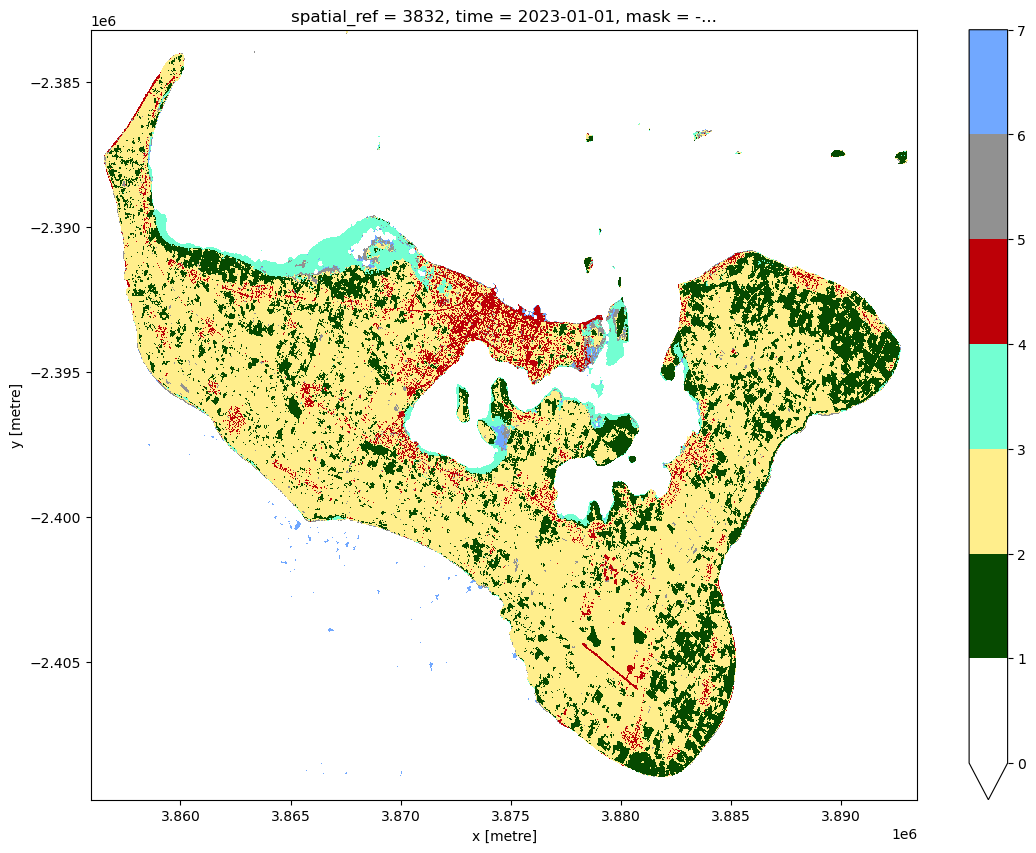

In [32]:
values_list = [c[0] for c in classes]
color_list = [c[2] for c in classes]

# Build a listed colormap.
c_map = colors.ListedColormap(color_list)
bounds = values_list + [7]
norm = colors.BoundaryNorm(bounds, c_map.N)

predicted_int.plot.imshow(cmap=c_map, norm=norm, size=10)

In [33]:
predicted_int.odc.write_cog(f"{version}-prediction-3.tiff")

PosixPath('nm-tongatapu-20042026-prediction-3.tiff')

In [34]:
training

,LULC_code,LULC_class,geometry
0,6,Water,POINT (-175.32648 -21.05595)
1,6,Water,POINT (-175.36156 -21.09345)
2,6,Water,POINT (-175.12939 -21.27945)
3,6,Water,POINT (-175.02447 -21.1477)
4,6,Water,POINT (-175.31365 -21.16867)
...,...,...,...
985,4,Settlements,POINT (-175.1994 -21.13518)
986,4,Settlements,POINT (-175.19913 -21.13671)
987,4,Settlements,POINT (-175.20174 -21.13612)
988,4,Settlements,POINT (-175.20039 -21.13224)


In [37]:
# df = pd.read_csv("nm-tongatapu-09122025-training.csv")

In [38]:
df

variable              nir  red  blue  green  emad  smad  bcmad  nir08  nir09  \
y          x                                                                   
-2383205.0 3855935.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
           3855945.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
           3855955.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
           3855965.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
           3855975.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
...                   ...  ...   ...    ...   ...   ...    ...    ...    ...   
-2409735.0 3893415.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
           3893425.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
           3893435.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
           3893445.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   
           3893455.0  0.0  0.0   0.0    0.0   0.0   0.0    0.0    0.0    0.0   

variable              swir16  ...  b_g  b_r  swir22_swir16  mci  ndci  nbi  \
y          x                  ...                                            
-2383205.0 3855935.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
           3855945.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
           3855955.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
           3855965.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
           3855975.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
...                      ...  ...  ...  ...            ...  ...   ...  ...   
-2409735.0 3893415.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
           3893425.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
           3893435.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
           3893445.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   
           3893455.0     0.0  ...  0.0  0.0            0.0  0.0   0.0  0.0   

variable              ndmi  bsi  awei  tc_wetness  
y          x                                       
-2383205.0 3855935.0   0.0  0.0   0.0         0.0  
           3855945.0   0.0  0.0   0.0         0.0  
           3855955.0   0.0  0.0   0.0         0.0  
           3855965.0   0.0  0.0   0.0         0.0  
           3855975.0   0.0  0.0   0.0         0.0  
...                    ...  ...   ...         ...  
-2409735.0 3893415.0   0.0  0.0   0.0         0.0  
           3893425.0   0.0  0.0   0.0         0.0  
           3893435.0   0.0  0.0   0.0         0.0  
           3893445.0   0.0  0.0   0.0         0.0  
           3893455.0   0.0  0.0   0.0         0.0  

[9960462 rows x 32 columns]

In [39]:
len(df)

9960462

In [41]:
# print(df["LULC_code"].value_counts())
# # df = training['LULC_code'] != 8